<a href="https://colab.research.google.com/github/ErnestoS215/GLAB-386.3.13---How-do-I-select-Columns-and-Rows-of-a-Panda-DataFrame-using-Square-notation/blob/main/GLAB_386_3_13_Select_Columns_and_Rows_of_a_Pandas_DataFrame_using_Square_notation_%5B%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Guided Lab 386.3.13 - Select Columns and Rows of a Pandas DataFrame using Square notation []**

---



## **Lab Objective**

In this lab, learners practice how to **select columns** and **filter rows** in a **Pandas DataFrame** using square bracket notation `[]`.

### **Key takeaways**
- Select a **single column** using `df['column_name']`.
- Select **multiple columns** using `df[['col1', 'col2']]`.
- Filter rows with **comparison operators** such as `==`, `>`, and `<`.
- Combine conditions with **logical operators** such as `&` and `|`.
- Filter rows with **string methods** such as `.str.startswith()` and `.str.endswith()`.
- Use `.isin()` to make multi-value filtering easier to read.

##**Learning Objective:**

By the end this lab, learners will be able t:
- Select any specified column/columns and Row/Rows from Pandas Dataframe.
- Filter rows using conditions.
- Utilize specialized functions like .isin() for precise filtering, like selecting data for specific years or categories.

## **Introduction**

### **Viewing column names**
Use the `columns` attribute to inspect the available fields in a DataFrame.

- Get all column names:
  ```python
  df.columns
  ```

- Get one column name by index position:
  ```python
  df.columns[1]
  ```

- Get multiple column names by index position:
  ```python
  df.columns[[0, 3, 4]]
  ```

### **Selecting columns with square brackets `[]`**
- Select a **single column**:
  ```python
  df['colName']
  ```

- Select **multiple columns**:
  ```python
  df[['colName1', 'colName2']]
  ```

### **Filtering rows**
To filter rows, place a Boolean condition inside square brackets:

```python
df[df['quantity'] > 350]
```

Only the rows where the condition evaluates to `True` are returned.
---




---

## **Dataset**

In this lab, we will use [cars.json](https://drive.google.com/file/d/1CXAK8gbuLtc2NNOXVUgmja8fDg0TrNZm/view) dataset, Let import cars dataset in Panda dataframe.

In [1]:
import pandas as pd
df_cars = pd.read_json('cars.json')
df_cars.head()


,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,quantity,city
0,Chevrolet Vega,25.0,4,140.0,75,2542,17.0,74,US,177,NJ
1,Chevrolet Vega (sw),22.0,4,140.0,72,2408,19.0,71,US,91,DALLAS
2,Chevrolet Vega 2300,28.0,4,140.0,90,2264,15.5,71,US,74,TEXAS
3,Chevrolet Woody,24.5,4,98.0,60,2164,22.1,76,US,241,OH
4,Chevrolete Chevelle Malibu,16.0,6,250.0,105,3897,18.5,75,US,206,NewYork


## **Explore the DataFrame First**

Before filtering rows and columns, it is helpful to inspect the dataset structure.

Lets Get all column names:

In [2]:
df_cars.columns

Index(['Car', 'MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model', 'Origin', 'quantity', 'city'],
      dtype='object')

In [3]:
df_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car           161 non-null    object 
 1   MPG           161 non-null    float64
 2   Cylinders     161 non-null    int64  
 3   Displacement  161 non-null    float64
 4   Horsepower    161 non-null    int64  
 5   Weight        161 non-null    int64  
 6   Acceleration  161 non-null    float64
 7   Model         161 non-null    int64  
 8   Origin        161 non-null    object 
 9   quantity      161 non-null    int64  
 10  city          161 non-null    object 
dtypes: float64(3), int64(5), object(3)
memory usage: 14.0+ KB


#**How do I select specific columns from a DataFrame?**

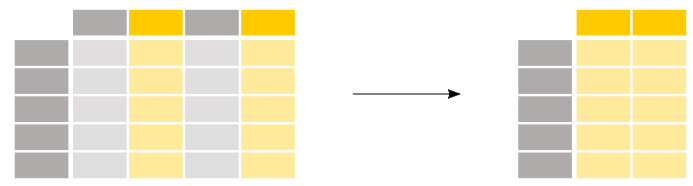

## **Example 1: Select one column**

Suppose we want to see the **car names** only.

In [4]:
df_cars['Car']

,Car
0,Chevrolet Vega
1,Chevrolet Vega (sw)
2,Chevrolet Vega 2300
3,Chevrolet Woody
4,Chevrolete Chevelle Malibu
...,...
156,Mercury Capri v6
157,Mercury Cougar Brougham
158,Mercury Grand Marquis
159,Mercury Lynx l


## **Example 2: Preview one column**

Use `.head()` when you want to preview only the first few values.

In [5]:
df_cars['Car'].head(10)

,Car
0,Chevrolet Vega
1,Chevrolet Vega (sw)
2,Chevrolet Vega 2300
3,Chevrolet Woody
4,Chevrolete Chevelle Malibu
5,Chevy C20
6,Chevy S-10
7,Chrysler Cordoba
8,Chrysler Lebaron Medallion
9,Chrysler Lebaron Salon


## **Example 3: Select multiple columns**

Suppose we want to see the **car name**, **model**, and **quantity** columns together.

In [6]:
df_cars[['Car','Model', 'quantity']]

,Car,Model,quantity
0,Chevrolet Vega,74,177
1,Chevrolet Vega (sw),71,91
2,Chevrolet Vega 2300,71,74
3,Chevrolet Woody,76,241
4,Chevrolete Chevelle Malibu,75,206
...,...,...,...
156,Mercury Capri v6,73,158
157,Mercury Cougar Brougham,77,27
158,Mercury Grand Marquis,79,332
159,Mercury Lynx l,82,425




---



#**How do I filter specific rows from a DataFrame?**

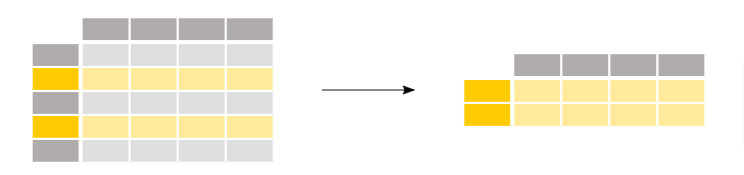

- Pandas lets you filter data by conditions over row/column values.
- We can create very powerful and sophisticated expressions by combining logical operations and comparison operators.


### **Example 4: Select rows where `MPG` is exactly `17.6`**

In [7]:
df_cars[df_cars.MPG == 17.6]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,quantity,city
9,Chrysler Lebaron Salon,17.6,6,225.0,85,3465,16.6,81,US,412,TEXAS
101,Ford LTD Landau,17.6,8,302.0,129,3725,13.4,79,US,331,NewYork


### **Alternatively: We can use .eq() function**

- The `eq()` function is used to perform element-wise comparison (equal to) between values.
- It checks whether values are equal (==).
- Returns True where values are equal and False where they are not.



In [8]:
df_cars[df_cars['MPG'].eq(17.6)]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,quantity,city
9,Chrysler Lebaron Salon,17.6,6,225.0,85,3465,16.6,81,US,412,TEXAS
101,Ford LTD Landau,17.6,8,302.0,129,3725,13.4,79,US,331,NewYork


###**Example 5: Get only those cars whose quantity is greater than 350.**

- We can use a logical operator, such as '>', to draw comparisons.

In [9]:
df_cars['quantity']<350

,quantity
0,True
1,True
2,True
3,True
4,True
...,...
156,True
157,True
158,True
159,False


In [10]:
getQuantity = df_cars[df_cars["quantity"] > 350]
print(getQuantity)

                            Car   MPG  Cylinders  Displacement  Horsepower  \
8    Chrysler Lebaron Medallion  26.0          4         156.0          92   
9        Chrysler Lebaron Salon  17.6          6         225.0          85   
15                 Datsun 200SX  32.9          4         119.0         100   
18                   Datsun 210  40.8          4          85.0          65   
19               Datsun 210 MPG  37.0          4          85.0          65   
20                Datsun 280-ZX  32.7          6         168.0         132   
21                   Datsun 310  37.2          4          86.0          65   
22                Datsun 310 GX  38.0          4          91.0          67   
25         Datsun 510 Hatchback  37.0          4         119.0          92   
30            Datsun 810 Maxima  24.2          6         146.0         120   
37               Dodge Aries SE  29.0          4         135.0          84   
38       Dodge Aries Wagon (sw)  25.8          4         156.0  

### **Example 6: Get cars whose `quantity` is greater than `350` and whose `Cylinders` are less than `4`**

When combining conditions:
- use `&` for **AND**
- wrap each condition in parentheses

In [11]:
filtered_cars = df_cars[(df_cars['quantity'] > 350) & (df_cars['Cylinders'] < 4)]
filtered_cars


,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,quantity,city
151,Mazda RX-7 GS,23.7,3,70.0,100,2420,12.5,80,Japan,379,NewYork


## **Example 7: Get all cars for city values matching `TEXAS` and `New York`**

Some datasets store the city as `NewYork` while others store it as `New York`.  
The code below normalizes spaces so the filter works in either case.

In [12]:
df_cars[((df_cars['city'] == 'TEXAS') | (df_cars['city'] == 'NewYork'))]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,quantity,city
2,Chevrolet Vega 2300,28.0,4,140.0,90,2264,15.5,71,US,74,TEXAS
4,Chevrolete Chevelle Malibu,16.0,6,250.0,105,3897,18.5,75,US,206,NewYork
6,Chevy S-10,31.0,4,119.0,82,2720,19.4,82,US,7,NewYork
9,Chrysler Lebaron Salon,17.6,6,225.0,85,3465,16.6,81,US,412,TEXAS
11,Chrysler New Yorker Brougham,13.0,8,440.0,215,4735,11.0,73,US,139,NewYork
...,...,...,...,...,...,...,...,...,...,...,...
150,Mazda RX-4,21.5,3,80.0,110,2720,13.5,77,Japan,288,NewYork
151,Mazda RX-7 GS,23.7,3,70.0,100,2420,12.5,80,Japan,379,NewYork
154,Mercedes-Benz 280s,16.5,6,168.0,120,3820,16.7,76,Europe,256,TEXAS
156,Mercury Capri v6,21.0,6,155.0,107,2472,14.0,73,US,158,NewYork


## **Alternate approach: Use `.isin()`**

`.isin()` is often easier to read than chaining multiple equality checks.

In [13]:
df_cars[df_cars['city'].isin(['TEXAS','NewYork'])]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,quantity,city
2,Chevrolet Vega 2300,28.0,4,140.0,90,2264,15.5,71,US,74,TEXAS
4,Chevrolete Chevelle Malibu,16.0,6,250.0,105,3897,18.5,75,US,206,NewYork
6,Chevy S-10,31.0,4,119.0,82,2720,19.4,82,US,7,NewYork
9,Chrysler Lebaron Salon,17.6,6,225.0,85,3465,16.6,81,US,412,TEXAS
11,Chrysler New Yorker Brougham,13.0,8,440.0,215,4735,11.0,73,US,139,NewYork
...,...,...,...,...,...,...,...,...,...,...,...
150,Mazda RX-4,21.5,3,80.0,110,2720,13.5,77,Japan,288,NewYork
151,Mazda RX-7 GS,23.7,3,70.0,100,2420,12.5,80,Japan,379,NewYork
154,Mercedes-Benz 280s,16.5,6,168.0,120,3820,16.7,76,Europe,256,TEXAS
156,Mercury Capri v6,21.0,6,155.0,107,2472,14.0,73,US,158,NewYork


### **Boolean verification example**

This returns a Boolean Series showing whether each row matches one of the selected cities.

In [14]:
df_cars['city'].isin(["San TEXAS", "NewYork"])

,city
0,False
1,False
2,False
3,False
4,True
...,...
156,True
157,False
158,False
159,False




---
##**What is .str in Pandas?**

- The `.str` accessor is used to apply string operations on a Pandas Series (column) and Dataframe.

- By using `.str` accessor, we can enable string functions and can apply on pandas dataframe.


You can use it to:
- check whether text starts with certain letters
- check whether text ends with certain letters
- measure string length
- clean and transform text data

**Common .str Functions are:**
- df['Name'].str.contains('a')
- df['Name'].str.startswith('J')
- df['Name'].str.endswith('n')
- df['Name'].str.len()
- df['Name'].str.upper()
- df['Name'].str.lower()
- df['Name'].str.title()
- df['Email'].str.split('@')

## **Example 8: Get cars with names that start with `M`**

In [15]:
df_cars[df_cars['Car'].str.startswith('M')]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,quantity,city
140,Mazda 626,31.3,4,120.0,75,2542,17.5,80,Japan,364,OH
141,Mazda 626,31.6,4,120.0,74,2635,18.3,81,Japan,403,NewYork
142,Mazda GLC,46.6,4,86.0,65,2110,17.9,80,Japan,367,NJ
143,Mazda GLC 4,34.1,4,91.0,68,1985,16.0,81,Japan,394,DALLAS
144,Mazda GLC Custom,31.0,4,91.0,68,1970,17.6,82,Japan,423,TEXAS
145,Mazda GLC Custom l,37.0,4,91.0,68,2025,18.2,82,Japan,422,OH
146,Mazda GLC Deluxe,32.8,4,78.0,52,1985,19.4,78,Japan,291,NewYork
147,Mazda GLC Deluxe,34.1,4,86.0,65,1975,15.2,79,Japan,7,NJ
148,Mazda RX2 Coupe,19.0,3,70.0,97,2330,13.5,72,Japan,116,DALLAS
149,Mazda RX3,18.0,3,70.0,90,2124,13.5,73,Japan,156,TEXAS


## **Example 9: Get cars with names that end with `m`**



In [16]:
df_cars[df_cars['Car'].str.endswith('m')]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,quantity,city
11,Chrysler New Yorker Brougham,13.0,8,440.0,215,4735,11.0,73,US,139,NewYork
50,Dodge Colt Hatchback Custom,35.7,4,98.0,80,1915,14.4,79,US,340,NewYork
51,Dodge Colt m/m,33.5,4,98.0,83,2075,15.9,77,US,283,NJ
52,Dodge Coronet Brougham,16.0,8,318.0,150,4190,13.0,76,US,233,DALLAS
53,Dodge Coronet Custom,15.0,8,318.0,150,3777,12.5,73,US,134,TEXAS
57,Dodge Dart Custom,15.0,8,318.0,150,3399,11.0,73,US,166,DALLAS
61,Dodge Monaco Brougham,15.5,8,318.0,145,4140,13.7,77,US,268,NJ
71,Fiat Strada Custom,37.3,4,91.0,69,2130,14.7,79,Europe,349,NJ
144,Mazda GLC Custom,31.0,4,91.0,68,1970,17.6,82,Japan,423,TEXAS
157,Mercury Cougar Brougham,15.0,8,302.0,130,4295,14.9,77,US,27,NJ


## **Example 10: Filter rows where the car name length is greater than `20`**



**The len( ) function calculates length of iterable.**

In [17]:
df_cars[df_cars['Car'].str.len()>20]

,Car,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model,Origin,quantity,city
4,Chevrolete Chevelle Malibu,16.0,6,250.0,105,3897,18.5,75,US,206,NewYork
8,Chrysler Lebaron Medallion,26.0,4,156.0,92,2585,14.5,82,US,434,DALLAS
9,Chrysler Lebaron Salon,17.6,6,225.0,85,3465,16.6,81,US,412,TEXAS
10,Chrysler Lebaron Town @ Country (sw),18.5,8,360.0,150,3940,13.0,79,US,337,OH
11,Chrysler New Yorker Brougham,13.0,8,440.0,215,4735,11.0,73,US,139,NewYork
12,Chrysler Newport Royal,13.0,8,400.0,190,4422,12.5,72,US,115,NJ
34,Datsun F-10 Hatchback,33.5,4,85.0,70,1945,16.8,77,Japan,265,TEXAS
38,Dodge Aries Wagon (sw),25.8,4,156.0,92,2620,14.4,81,US,385,DALLAS
50,Dodge Colt Hatchback Custom,35.7,4,98.0,80,1915,14.4,79,US,340,NewYork
52,Dodge Coronet Brougham,16.0,8,318.0,150,4190,13.0,76,US,233,DALLAS


## **Example 11: Handle `NaN` values**

The example below creates a small DataFrame with missing values and removes columns that contain `NaN`.

In [18]:
import numpy as np
import pandas as pd

# Initializing the nested list with Data set
employee_list = [['James', 36, 75, 5428000],
               ['Villers', 38, 74, 3428000],
               ['VKole', 31, 70, 8428000],
               ['Smith', 34, 80, 4428000],
               ['Gayle', 40, 100, 4528000],
               ['Adam', 40, np.nan, 4528000],
               ['Rooter', 33, 72, 7028000],
               ['Peterson', 42, 85, 2528000],
               ['lynda', 42, 85, np.nan],
               [np.nan, 42, 85, np.nan],
               ['Jenny', np.nan, 100, 25632],
               ['Kenn', np.nan, 110, 25632],
                ['Aly', np.nan, 90, 25582],
               ['John', 41, 85, 1528000]]

# creating a pandas dataframe
df = pd.DataFrame(employee_list, columns=['Name', 'Age', 'Weight', 'Salary'])

print(df)

print('---- after dropping or cleaning the missing data ---')
df = df.dropna()
df


        Name   Age  Weight     Salary
0      James  36.0    75.0  5428000.0
1    Villers  38.0    74.0  3428000.0
2      VKole  31.0    70.0  8428000.0
3      Smith  34.0    80.0  4428000.0
4      Gayle  40.0   100.0  4528000.0
5       Adam  40.0     NaN  4528000.0
6     Rooter  33.0    72.0  7028000.0
7   Peterson  42.0    85.0  2528000.0
8      lynda  42.0    85.0        NaN
9        NaN  42.0    85.0        NaN
10     Jenny   NaN   100.0    25632.0
11      Kenn   NaN   110.0    25632.0
12       Aly   NaN    90.0    25582.0
13      John  41.0    85.0  1528000.0
---- after dropping or cleaning the missing data ---


,Name,Age,Weight,Salary
0,James,36.0,75.0,5428000.0
1,Villers,38.0,74.0,3428000.0
2,VKole,31.0,70.0,8428000.0
3,Smith,34.0,80.0,4428000.0
4,Gayle,40.0,100.0,4528000.0
6,Rooter,33.0,72.0,7028000.0
7,Peterson,42.0,85.0,2528000.0
13,John,41.0,85.0,1528000.0


In [19]:
drop_na_cols_strategy = df.dropna(axis=1)
drop_na_cols_strategy


,Name,Age,Weight,Salary
0,James,36.0,75.0,5428000.0
1,Villers,38.0,74.0,3428000.0
2,VKole,31.0,70.0,8428000.0
3,Smith,34.0,80.0,4428000.0
4,Gayle,40.0,100.0,4528000.0
6,Rooter,33.0,72.0,7028000.0
7,Peterson,42.0,85.0,2528000.0
13,John,41.0,85.0,1528000.0


##**Submission**
- Submit your completed lab using the Start Assignment button on the assignment page in Canvas.
- Your submission can be include:
  - if you are using notebook then, all tasks should be written and submitted in a single notebook file, for example: (**your_name_labname.ipynb**).
  - if you are using python script file, all tasks should be written and submitted in a single python script file for example: **(your_name_labname.py)**.
- Add appropriate comments and any additional instructions if required.
